Ce notebook a pour objectif le suivi de la deuxième phase du projet project_eleven, et constitue la suite logique du premier notebook qui portait sur des données issues du jeu Football Manager 2024. Ici, l'objectif est le même que précédemment, mais appliqué à des données réelles. On se donne pour but d'entraîner un modèle ML pour prédire le résultat d'un match de football (victoire, nul ou défaite) à l'aide de données issues des anciennes saisons de Laliga. 

In [4]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import poisson

from pathlib import Path

# Feature engineering factorisé (voir src/features.py) : une seule
# implémentation, réutilisée par la construction du dataset ET le tuning de K.
from src.features import build_pre_match_features

# Graine unique pour toute reproductibilité (modèles, éventuels tirages).
RANDOM_STATE = 42


Pour ce faire, des données de tous les matchs de Liga allant de la saison 2020-2021 à la saison 2024-2025 sont récupérées sur le site fbref. On récupère un tableau par saison contenant, pour tous les matchs: la date du match, le jour, l'heure, l'équipe à domicile, l'xG de l'équipe à domicile, le score, l'xG de l'équipe à l'extérieur, l'équipe extérieure, le nombre de spectateurs, le lieu du match et l'arbitre. Seules certaines de ces données nous intéressent pour la suite, une fusion des tableaux est donc effectué ainsi qu'un nettoyage.

In [6]:
# ==========================================================
# Chargement des données brutes (fixtures fbref, une par saison)
# ==========================================================
# Les 6 CSV sont fournis dans data/ : une ligne = un match joué,
# avec les colonnes fbref d'origine. Ils remplacent l'ancienne étape
# de scraping HTML, ce qui rend ce notebook reproductible tel quel
# (un simple "Restart & Run All" après clonage du repo suffit).
#
# Remarque : la saison 2025-2026 n'expose pas de colonne xG sur fbref ;
# après la fusion, xG_home / xG_away y valent donc NaN. C'est attendu
# et géré en aval par le SimpleImputer(strategy="median") du pipeline.

from pathlib import Path

DATA_DIR = Path("data")

csv_files = [
    "laliga_2020_2021_fixtures.csv",
    "laliga_2021_2022_fixtures.csv",
    "laliga_2022_2023_fixtures.csv",
    "laliga_2023_2024_fixtures.csv",
    "laliga_2024_2025_fixtures.csv",
    "laliga_2025_2026_fixtures.csv",
]

dfs = [pd.read_csv(DATA_DIR / f) for f in csv_files]

# Fusion des saisons puis nettoyage / renommage des colonnes utiles
df_all = pd.concat(dfs, axis=0, ignore_index=True)
df_all = df_all.drop(columns=["Wk", "Attendance", "Venue", "Referee", "Match Report", "Notes"])

df_all = df_all.rename(columns={
    "Home": "home_team",
    "Away": "away_team",
    "xG": "xG_home",
    "xG.1": "xG_away",
})

# Score du type "2–1" -> score_home = 2, score_away = 1
df_all[["score_home", "score_away"]] = (
    df_all["Score"]
    .str.replace("–", "-", regex=False)   # tiret typographique fbref -> tiret ASCII
    .str.split("-", expand=True)
    .astype(int)
)
df_all = df_all.drop(columns=["Score"])

# Fichier intermédiaire consommé par la suite du notebook (régénérable)
df_all.to_csv("laliga_matchs_20-26.csv", index=False)
df_all.head()


,Day,Date,Time,home_team,xG_home,xG_away,away_team,score_home,score_away
0,Sat,2020-09-12,16:00,Eibar,0.4,0.6,Celta Vigo,0,0
1,Sat,2020-09-12,18:30,Granada,0.4,0.5,Athletic Club,2,0
2,Sat,2020-09-12,21:00,Cádiz,0.7,0.8,Osasuna,0,2
3,Sun,2020-09-13,14:00,Alavés,1.2,0.4,Betis,0,1
4,Sun,2020-09-13,16:00,Valladolid,0.8,0.3,Real Sociedad,1,1


On dispose à présent d'un fichier de données .csv contenant, pour tous les matchs de Liga des saison 2020-2021 à 2024-2025: la date du match, l'heure, le jour, l'équipe à domicile, l'xG de l'équipe à domicile, le score de l'équipe à domicile, l'équipe à l'extérieure, l'xG de l'équipe à l'extérieure, et le score de l'équipe à l'extérieure. A présent, l'objectif est de construire à partir de ces données un nouveau dataset de features pertinentes pour la prédiction des résultats des matchs. Pour cela, on va construire un certains nombres de features à partir des données disponibles: 

    -elo_home: notation de l'équipe à domicile basée sur les résultats des matchs précédents de cette équipe
    -elo_away: notation de l'équipe à l'extérieure basée sur les résultats des matchs précédents de cette équipe
    -elo_diff: différence d'elo entre les deux équipes
    -form_xG_home_5: moyenne d'xG de l'équipe à domicile sur ses cinq derniers matchs
    -form_xG_away_5: même principe pour l'équipe à l'extérieur
    -diff_xG: différence de la moyenne d'xG des deux équipes
    -form_points_home_5: moyenne des points de l'équipe à domicile sur ses cinq derniers matchs (3 points en cas de victoire, 1.5 en cas de nul, 0 en cas de défaite)
    -form_points_away_5: même principe pour l'équipe à l'extérieure
    -form_goal_diff_home_5: moyenne du goal difference (buts marqués - buts encaissés) sur les cinq derniers matchs de l'équipe à domicile
    -form_goal_diff_away_5: même principe pour l'équipe à l'extérieure
    -rest_diff: différence entre le repos des deux équipes, calculée à partir des intervalles de temps entre le match présent et les derniers matchs des deux équipes

Il est intéressant de se pencher plus précisément sur le calcul de l'Elo. Ce système est largement inspiré de systèmes tels que celui qu'on peut voir aux échecs. Chaque équipe part avec un Elo de base de 1500 (la valeur intrinsèque de l'Elo d'une équipe n'a aucune importance, ce sont les différences qui comptent). Avant chaque match, l'Elo de l'équipe est recalculé en fonction des résultats de l'équipe lors des matchs précédents. Pour prendre en compte le résultat d'un match dans le calcul de l'Elo d'une équipe, on calcule d'abord la probabilité de victoire de chaque équipe selon une fonction logistique:

$E_h = \frac{1}{1 + 10^{-\frac{Elo_h - Elo_a}{400}}}$

$E_a = 1 - E_h$

L'Elo est ensuite recalculé en fonction de la différence entre le résultat de l'équipe et sa probabilité de victoire selon:

$Elo_h += K*(S_h - E_h)$

$Elo_a += K*(S_a - E_a)$

Avec S = 1 en cas de victoire, 0.5 en cas de nul et 0 en cas de défaite. K est un paramètre ajustable qui module la sensibilité de l'Elo et dont l'influence sur les prédictions du modèle pourra être étudiée. A noté qu'on choisit pour K de départ le K optimal trouvé pour les données issues de FM24 afin de commencer avec un K qu'on espère proche de l'optimum.

l'xG, diminutif de Expected Goal, désigne la probabilité qu'un tir soit converti en but. Il permet d'évaluer le nombre de buts "qu'aurait du marquer" une équipe durant un match. 

In [7]:
# ==========================================================
# Construction des features pré-match
# ==========================================================
# Toute la logique (Elo, forme récente, repos, cible) vit désormais dans
# src/features.py et n'est écrite qu'une seule fois. La fonction lit les
# features AVANT de mettre à jour l'Elo/l'historique -> pas de fuite temporelle.
df_all = pd.read_csv("laliga_matchs_20-26.csv")

df_features = build_pre_match_features(df_all, k_elo=20, n_form=5, base_elo=1500)
df_features.to_csv("liga_pre_match_features.csv", index=False)

df_features.head()


,date,day,home_team,away_team,elo_home,elo_away,elo_diff,form_xG_home_5,form_xG_away_5,xG_diff,form_points_home_5,form_points_away_5,form_goal_diff_home_5,form_goal_diff_away_5,rest_diff,target
0,2020-09-12,6,Eibar,Celta Vigo,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
1,2020-09-12,6,Granada,Athletic Club,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2
2,2020-09-12,6,Cádiz,Osasuna,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2020-09-13,7,Alavés,Betis,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2020-09-13,7,Valladolid,Real Sociedad,1500.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1


Une fois les features construites, on évalue le modèle par un **split temporel** — indispensable pour des séries chronologiques, où un découpage aléatoire ferait fuiter de l'information du futur vers le passé. On entraîne sur les **trois premières saisons** (2020‑2021 à 2022‑2023, soit 1140 matchs) et on teste sur les **deux saisons suivantes** (2023‑2024 et 2024‑2025, soit 760 matchs). La saison 2025‑2026, encore incomplète et dépourvue de colonne xG sur fbref, est mise de côté pour cette évaluation.

Le modèle est une **régression logistique multinomiale**, encapsulée avec l'imputation (médiane) et la normalisation dans un `Pipeline` afin que ces étapes soient apprises sur le seul jeu d'entraînement. La classe cible prend trois valeurs :

   - y = 2 : victoire à domicile
   - y = 1 : match nul
   - y = 0 : défaite à domicile (victoire à l'extérieur)

On mesure l'**accuracy**, la **log‑loss** et la **matrice de confusion**. Pour que ces chiffres soient interprétables, on les compare systématiquement à deux **baselines** :

   - **prior de classe** (« toujours domicile ») : prédit toujours l'issue la plus fréquente du train ; son accuracy vaut le taux de victoire à domicile sur le test ;
   - **Elo seul** : une régression logistique n'utilisant que `elo_diff`, pour isoler l'apport réel des autres features (forme, xG, repos) au‑delà de la simple différence de niveau.

Train : 1140 matchs  (2020-09-12 -> 2023-06-04)
Test  :  760 matchs  (2023-08-11 -> 2025-05-25)
Taux de victoire à domicile (test) : 0.442

=== Comparaison sur le jeu de test (2 saisons) ===
                                 modèle  accuracy  log_loss
Régression logistique (toutes features)    0.5355    0.9738
   Baseline — prior (toujours domicile)    0.4421    1.0728
         Baseline — Elo seul (elo_diff)    0.5355    0.9672

=== Rapport de classification (modèle principal) ===
              precision    recall  f1-score   support

 défaite (0)       0.51      0.58      0.54       220
     nul (1)       0.00      0.00      0.00       204
victoire (2)       0.55      0.83      0.67       336

    accuracy                           0.54       760
   macro avg       0.35      0.47      0.40       760
weighted avg       0.39      0.54      0.45       760



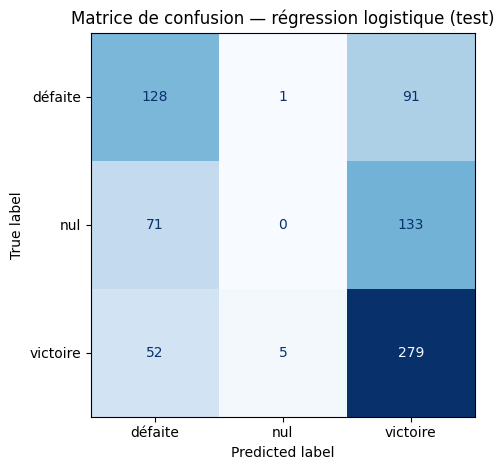

In [8]:
# ==========================================================
# Évaluation : split temporel 3 saisons (train) / 2 saisons (test)
# ==========================================================
df = pd.read_csv("liga_pre_match_features.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

meta_cols = ["date", "home_team", "away_team"]
feature_cols = [c for c in df.columns if c not in meta_cols + ["target"]]

# Les saisons de Liga vont d'août à mai : on découpe donc sur des bornes d'été.
TRAIN_END = pd.Timestamp("2023-08-01")   # fin des 3 premières saisons (train)
TEST_END  = pd.Timestamp("2025-08-01")   # fin des 2 saisons suivantes (test)

train_mask = df["date"] < TRAIN_END
test_mask  = (df["date"] >= TRAIN_END) & (df["date"] < TEST_END)
# La saison 2025-2026 (date >= TEST_END, sans xG) est volontairement exclue.

df_train, df_test = df[train_mask].copy(), df[test_mask].copy()
X_train, y_train = df_train[feature_cols], df_train["target"].astype(int)
X_test,  y_test  = df_test[feature_cols],  df_test["target"].astype(int)

LABELS = [0, 1, 2]   # ordre fixe pour les métriques et la matrice de confusion
print(f"Train : {len(df_train):4d} matchs  ({df_train['date'].min().date()} -> {df_train['date'].max().date()})")
print(f"Test  : {len(df_test):4d} matchs  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")
print(f"Taux de victoire à domicile (test) : {(y_test == 2).mean():.3f}")

# ----------------------------------------------------------
# Modèle principal : régression logistique multinomiale
# ----------------------------------------------------------
full_model = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=2000,
                               random_state=RANDOM_STATE)),
])
full_model.fit(X_train, y_train)

# ----------------------------------------------------------
# Baselines de référence
# ----------------------------------------------------------
# (1) Prior de classe = "toujours domicile" : prédit la classe majoritaire
#     du train ; predict_proba renvoie les fréquences de classes du train.
prior_model = DummyClassifier(strategy="prior", random_state=RANDOM_STATE)
prior_model.fit(X_train, y_train)

# (2) Elo seul : même pipeline, mais sur la seule feature elo_diff.
elo_model = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=2000,
                               random_state=RANDOM_STATE)),
])
elo_model.fit(X_train[["elo_diff"]], y_train)

# ----------------------------------------------------------
# Comparaison accuracy / log-loss sur le test
# ----------------------------------------------------------
def scores(model, X):
    return (accuracy_score(y_test, model.predict(X)),
            log_loss(y_test, model.predict_proba(X), labels=LABELS))

acc_full,  ll_full  = scores(full_model,  X_test)
acc_prior, ll_prior = scores(prior_model, X_test)
acc_elo,   ll_elo   = scores(elo_model,   X_test[["elo_diff"]])

results = pd.DataFrame({
    "modèle":   ["Régression logistique (toutes features)",
                 "Baseline — prior (toujours domicile)",
                 "Baseline — Elo seul (elo_diff)"],
    "accuracy": [acc_full, acc_prior, acc_elo],
    "log_loss": [ll_full,  ll_prior,  ll_elo],
})
print("\n=== Comparaison sur le jeu de test (2 saisons) ===")
print(results.round(4).to_string(index=False))

# ----------------------------------------------------------
# Matrice de confusion + rapport détaillé (modèle principal)
# ----------------------------------------------------------
y_pred_full = full_model.predict(X_test)
print("\n=== Rapport de classification (modèle principal) ===")
print(classification_report(
    y_test, y_pred_full, labels=LABELS,
    target_names=["défaite (0)", "nul (1)", "victoire (2)"],
    zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_full, labels=LABELS,
    display_labels=["défaite", "nul", "victoire"],
    cmap="Blues", colorbar=False,
)
plt.title("Matrice de confusion — régression logistique (test)")
plt.tight_layout()
plt.show()


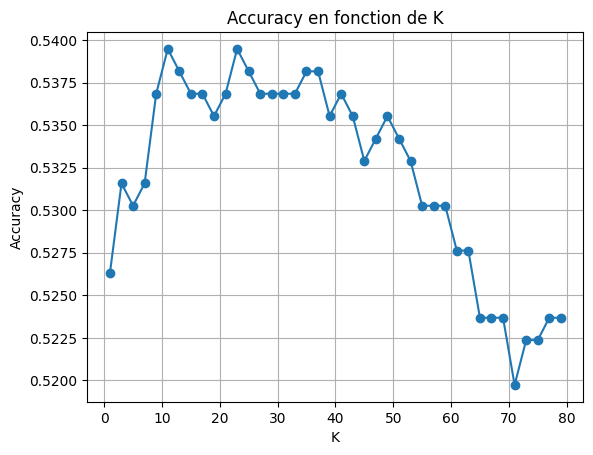

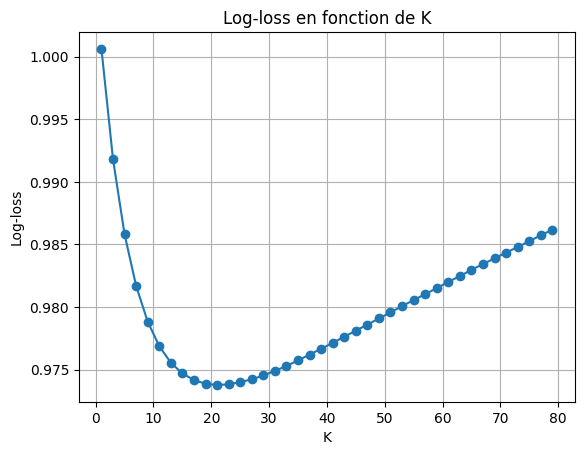

In [9]:
# ============================================
# Courbes Accuracy / Log-loss en fonction de K
# ============================================
# On réutilise build_pre_match_features (src/features.py) en faisant varier
# le seul facteur K de l'Elo, puis on évalue sur le même split que plus haut.

K_values = list(range(1, 81, 2))

# Mêmes bornes de split que la cellule d'évaluation (2025-26 exclue).
TRAIN_END = pd.Timestamp("2023-08-01")
TEST_END  = pd.Timestamp("2025-08-01")

results = []

for K_elo in K_values:
    df_k = build_pre_match_features(df_all, k_elo=K_elo, n_form=5, base_elo=1500)

    meta_cols = ["date", "home_team", "away_team"]
    Xk = df_k.drop(columns=meta_cols + ["target"])
    yk = df_k["target"]

    train_mask = df_k["date"] < TRAIN_END
    test_mask  = (df_k["date"] >= TRAIN_END) & (df_k["date"] < TEST_END)

    X_train_k, X_test_k = Xk[train_mask], Xk[test_mask]
    y_train_k, y_test_k = yk[train_mask], yk[test_mask]

    # Même pipeline que le modèle principal (imputation médiane -> robuste aux NaN).
    model = Pipeline(steps=[
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(solver="lbfgs", max_iter=1000,
                                   random_state=RANDOM_STATE)),
    ])
    model.fit(X_train_k, y_train_k)

    y_pred_k  = model.predict(X_test_k)
    y_proba_k = model.predict_proba(X_test_k)

    acc = accuracy_score(y_test_k, y_pred_k)
    ll  = log_loss(y_test_k, y_proba_k, labels=[0, 1, 2])

    results.append({"K": K_elo, "accuracy": acc, "log_loss": ll})

results_df = pd.DataFrame(results)

# --- Courbes ---
plt.figure()
plt.plot(results_df["K"], results_df["accuracy"], marker="o")
plt.xlabel("K"); plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de K")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(results_df["K"], results_df["log_loss"], marker="o")
plt.xlabel("K"); plt.ylabel("Log-loss")
plt.title("Log-loss en fonction de K")
plt.grid(True)
plt.show()


La log‑loss est très plate au voisinage de son minimum : `K = 20` se situe dans cette zone optimale (le minimum exact se trouve aux alentours de `K ≈ 20‑21`) tout en restant proche du maximum d'accuracy. On conserve donc `K = 20`. Il reste à examiner **sur quelles features** le modèle s'appuie réellement : comme les variables sont normalisées, les coefficients de la régression logistique sont directement comparables en amplitude d'une feature à l'autre.

Coefficients par classe (features standardisées) :
                       défaite (0)  nul (1)  victoire (2)  importance_globale
elo_diff                    -0.220    0.015         0.205               0.440
elo_away                     0.211   -0.061        -0.150               0.422
form_points_home_5           0.195   -0.063        -0.132               0.391
form_goal_diff_home_5       -0.150    0.057         0.093               0.300
elo_home                    -0.103   -0.039         0.142               0.284
form_points_away_5          -0.100   -0.014         0.115               0.229
form_xG_away_5               0.101   -0.047        -0.054               0.202
form_goal_diff_away_5        0.039    0.052        -0.091               0.183
day                         -0.027   -0.031         0.058               0.117
xG_diff                     -0.058    0.001         0.057               0.116
form_xG_home_5               0.023   -0.046         0.023               0.092
rest_diff    

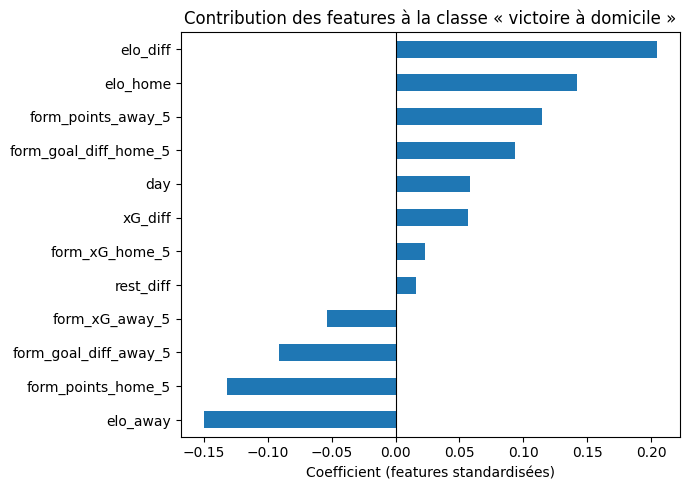

In [10]:
# ==========================================================
# Impact des features : coefficients de la régression logistique
# ==========================================================
# Les features étant standardisées (StandardScaler), les coefficients sont
# comparables entre eux : |coef| grand = feature à fort pouvoir discriminant
# pour la classe considérée. clf.coef_ a la forme (n_classes, n_features),
# soit une ligne par classe (0 = défaite, 1 = nul, 2 = victoire).
clf = full_model.named_steps["clf"]

coefs = pd.DataFrame(
    clf.coef_.T,
    index=feature_cols,
    columns=["défaite (0)", "nul (1)", "victoire (2)"],
)

# Tri par importance globale = somme des |coef| sur les trois classes.
coefs["importance_globale"] = coefs.abs().sum(axis=1)
coefs = coefs.sort_values("importance_globale", ascending=False)

print("Coefficients par classe (features standardisées) :")
print(coefs.round(3).to_string())

# Contribution de chaque feature à la classe "victoire à domicile".
ax = coefs["victoire (2)"].sort_values().plot(kind="barh", figsize=(7, 5))
ax.set_title("Contribution des features à la classe « victoire à domicile »")
ax.set_xlabel("Coefficient (features standardisées)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## Phase 3 — Chantier A : validation *walk-forward*

L'évaluation précédente repose sur **un seul** découpage train/test : c'est un unique point de mesure, sensible au choix des saisons de test. On le remplace ici par une validation **walk-forward**, plus robuste, qui rejoue plusieurs fois le schéma « entraîner sur le passé, tester sur la saison suivante » :

- **fenêtre extensible** (*expanding*) : on entraîne sur **toutes** les saisons antérieures à la saison de test ;
- **fenêtre glissante** (*sliding*) : on n'entraîne que sur les **2 saisons** précédentes, pour voir si les données anciennes aident ou nuisent.

Pour chaque *fold*, on mesure l'accuracy et la log-loss du modèle complet et des deux baselines (prior, Elo seul), puis on agrège en **moyenne ± écart-type**. On ajoute un **intervalle de confiance bootstrap** sur les prédictions *out-of-fold* poolées, et un **test anti-fuite** explicite vérifiant que les features ne dépendent que du passé.

In [11]:
# ==========================================================
# Phase 3 — Chantier A : préparation + test anti-fuite
# ==========================================================
# On repart des features déjà construites, on ajoute l'étiquette de saison
# et on écarte 2025-2026 (partielle, sans xG).
wf = pd.read_csv("liga_pre_match_features.csv", parse_dates=["date"])

def season_label(d):
    # Une saison de Liga va d'août (année n) à mai (année n+1).
    return f"{d.year - 1}-{d.year}" if d.month < 7 else f"{d.year}-{d.year + 1}"

wf["season"] = wf["date"].apply(season_label)
wf = wf[wf["season"] != "2025-2026"].reset_index(drop=True)

meta_cols = ["date", "home_team", "away_team", "season"]
feature_cols = [c for c in wf.columns if c not in meta_cols + ["target"]]
seasons = sorted(wf["season"].unique())
print("Saisons exploitables :", seasons)

# ----------------------------------------------------------
# Test anti-fuite : les features ne dépendent QUE du passé
# ----------------------------------------------------------
# Propriété attendue : les features d'un match ne dépendent que des matchs
# strictement antérieurs. On les reconstruit sur un PRÉFIXE des données
# (matchs avant juillet 2023) et on vérifie qu'elles coïncident, match par
# match, avec celles calculées sur le jeu COMPLET. On aligne sur l'identité
# (date, équipes) : l'ordre des matchs d'une même journée est sans effet sur
# les valeurs, une équipe ne jouant qu'une fois par jour.
raw = df_all.copy()
raw["Date"] = pd.to_datetime(raw["Date"])
feat_full   = build_pre_match_features(raw)
feat_prefix = build_pre_match_features(raw[raw["Date"] < pd.Timestamp("2023-07-01")])

key = ["date", "home_team", "away_team"]
check = feat_full.merge(feat_prefix, on=key, suffixes=("_full", "_pre"))
identical = all(
    (np.allclose(check[c + "_full"].fillna(-999), check[c + "_pre"].fillna(-999))
     if check[c + "_full"].dtype.kind in "biufc"
     else (check[c + "_full"].astype(str) == check[c + "_pre"].astype(str)).all())
    for c in feat_full.columns if c not in key
)
print(f"Test anti-fuite (features = fonction du passé seul) : "
      f"{'OK' if identical else 'ÉCHEC'}  sur {len(check)} matchs communs")
assert identical, "Fuite détectée : des features dépendent du futur !"


Saisons exploitables : ['2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']
Test anti-fuite (features = fonction du passé seul) : OK  sur 1140 matchs communs


In [12]:
# ----------------------------------------------------------
# Boucle walk-forward + baselines, par fold
# ----------------------------------------------------------
def make_full_pipeline():
    """Pipeline du modèle principal (réutilisé à chaque fold)."""
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(solver="lbfgs", max_iter=2000,
                                   random_state=RANDOM_STATE)),
    ])

def evaluate_fold(train_df, test_df):
    """Modèle complet + baselines (prior, Elo seul) sur un couple train/test."""
    y_tr = train_df["target"].astype(int)
    y_te = test_df["target"].astype(int)

    full  = make_full_pipeline().fit(train_df[feature_cols], y_tr)
    prior = DummyClassifier(strategy="prior", random_state=RANDOM_STATE).fit(train_df[feature_cols], y_tr)
    elo   = make_full_pipeline().fit(train_df[["elo_diff"]], y_tr)

    def metrics(model, X):
        return (accuracy_score(y_te, model.predict(X)),
                log_loss(y_te, model.predict_proba(X), labels=[0, 1, 2]))

    acc_full, ll_full   = metrics(full,  test_df[feature_cols])
    acc_prior, ll_prior = metrics(prior, test_df[feature_cols])
    acc_elo, ll_elo     = metrics(elo,   test_df[["elo_diff"]])

    res = dict(acc_full=acc_full, ll_full=ll_full, acc_prior=acc_prior,
               ll_prior=ll_prior, acc_elo=acc_elo, ll_elo=ll_elo)
    oof = (y_te.values,
           full.predict(test_df[feature_cols]),
           full.predict_proba(test_df[feature_cols]))
    return res, oof

def run_walk_forward(data, seasons, scheme="expanding", n_train=2):
    """Rejoue 'train sur le passé / test sur la saison suivante' pour chaque saison."""
    rows, oof_y, oof_pred, oof_proba = [], [], [], []
    for i, test_season in enumerate(seasons):
        if i == 0:
            continue                              # pas de passé pour la 1re saison
        if scheme == "expanding":
            train_seasons = seasons[:i]
        else:                                     # sliding
            if i < n_train:
                continue
            train_seasons = seasons[i - n_train:i]

        train_df = data[data["season"].isin(train_seasons)]
        test_df  = data[data["season"] == test_season]
        res, (y_v, pred_v, proba_v) = evaluate_fold(train_df, test_df)
        res.update(test_season=test_season, n_train=len(train_df), n_test=len(test_df))
        rows.append(res)
        oof_y.append(y_v); oof_pred.append(pred_v); oof_proba.append(proba_v)

    table = pd.DataFrame(rows)[["test_season", "n_train", "n_test",
                                "acc_full", "ll_full", "acc_prior",
                                "ll_prior", "acc_elo", "ll_elo"]]
    oof = (np.concatenate(oof_y), np.concatenate(oof_pred), np.concatenate(oof_proba))
    return table, oof

exp_table, exp_oof = run_walk_forward(wf, seasons, scheme="expanding")
sli_table, _       = run_walk_forward(wf, seasons, scheme="sliding", n_train=2)

def summarize(table, title):
    print(f"\n=== {title} ===")
    print(table.round(4).to_string(index=False))
    print(f"moyenne ± écart-type : "
          f"acc_full = {table.acc_full.mean():.3f} ± {table.acc_full.std():.3f}   |   "
          f"log_loss_full = {table.ll_full.mean():.3f} ± {table.ll_full.std():.3f}")
    print(f"                       "
          f"acc_elo  = {table.acc_elo.mean():.3f} ± {table.acc_elo.std():.3f}   |   "
          f"log_loss_elo  = {table.ll_elo.mean():.3f} ± {table.ll_elo.std():.3f}")

summarize(exp_table, "WALK-FORWARD EXPANDING (train = toutes les saisons antérieures)")
summarize(sli_table, "WALK-FORWARD SLIDING (2 saisons glissantes)")



=== WALK-FORWARD EXPANDING (train = toutes les saisons antérieures) ===
test_season  n_train  n_test  acc_full  ll_full  acc_prior  ll_prior  acc_elo  ll_elo
  2021-2022      380     380    0.4947   1.0801     0.4342    1.0778   0.4947  1.0319
  2022-2023      760     380    0.5368   1.0244     0.4789    1.0597   0.5447  1.0112
  2023-2024     1140     380    0.5342   0.9621     0.4395    1.0746   0.5368  0.9598
  2024-2025     1520     380    0.5395   0.9825     0.4447    1.0712   0.5342  0.9734
moyenne ± écart-type : acc_full = 0.526 ± 0.021   |   log_loss_full = 1.012 ± 0.052
                       acc_elo  = 0.528 ± 0.022   |   log_loss_elo  = 0.994 ± 0.033

=== WALK-FORWARD SLIDING (2 saisons glissantes) ===
test_season  n_train  n_test  acc_full  ll_full  acc_prior  ll_prior  acc_elo  ll_elo
  2022-2023      760     380    0.5368   1.0244     0.4789    1.0597   0.5447  1.0112
  2023-2024      760     380    0.5237   0.9716     0.4395    1.0753   0.5500  0.9639
  2024-2025      7

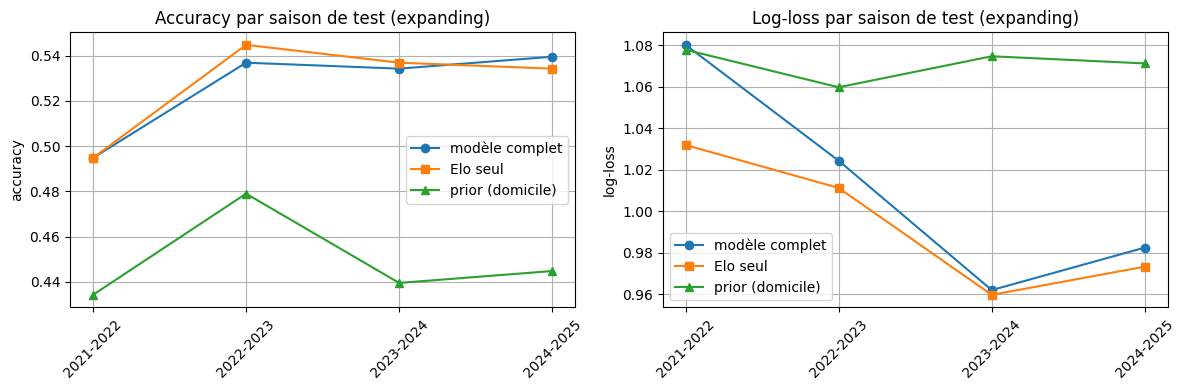

Prédictions out-of-fold poolées : 1520 matchs (saisons 2021-2022 à 2024-2025)
Accuracy : 0.526   IC95% [0.501, 0.553]
Log-loss : 1.012   IC95% [0.982, 1.044]


In [13]:
# ----------------------------------------------------------
# Courbes par saison de test + intervalles de confiance bootstrap
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, marker, lab in [("acc_full", "o", "modèle complet"),
                         ("acc_elo", "s", "Elo seul"),
                         ("acc_prior", "^", "prior (domicile)")]:
    axes[0].plot(exp_table["test_season"], exp_table[col], marker=marker, label=lab)
axes[0].set_title("Accuracy par saison de test (expanding)")
axes[0].set_ylabel("accuracy"); axes[0].grid(True); axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

for col, marker, lab in [("ll_full", "o", "modèle complet"),
                         ("ll_elo", "s", "Elo seul"),
                         ("ll_prior", "^", "prior (domicile)")]:
    axes[1].plot(exp_table["test_season"], exp_table[col], marker=marker, label=lab)
axes[1].set_title("Log-loss par saison de test (expanding)")
axes[1].set_ylabel("log-loss"); axes[1].grid(True); axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

def bootstrap_ci(y, y_pred, y_proba, n_boot=2000, seed=RANDOM_STATE):
    """IC95% de l'accuracy et de la log-loss par ré-échantillonnage des matchs."""
    rng = np.random.default_rng(seed)
    n = len(y); accs, lls = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        accs.append(accuracy_score(y[idx], y_pred[idx]))
        lls.append(log_loss(y[idx], y_proba[idx], labels=[0, 1, 2]))
    return np.percentile(accs, [2.5, 97.5]), np.percentile(lls, [2.5, 97.5])

y_oof, pred_oof, proba_oof = exp_oof
acc_ci, ll_ci = bootstrap_ci(y_oof, pred_oof, proba_oof)
print(f"Prédictions out-of-fold poolées : {len(y_oof)} matchs (saisons {seasons[1]} à {seasons[-1]})")
print(f"Accuracy : {accuracy_score(y_oof, pred_oof):.3f}   "
      f"IC95% [{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]")
print(f"Log-loss : {log_loss(y_oof, proba_oof, labels=[0, 1, 2]):.3f}   "
      f"IC95% [{ll_ci[0]:.3f}, {ll_ci[1]:.3f}]")


### Ce que la validation walk-forward apprend

- **Un chiffre plus sobre.** La moyenne walk-forward (accuracy ≈ 0.53, log-loss ≈ 1.01 en *expanding*) est légèrement inférieure au 0.536 du split unique 3/2 : ce dernier testait justement sur les saisons les plus récentes, celles qui bénéficient du plus grand historique d'entraînement. Le walk-forward fournit une estimation plus représentative, assortie de son incertitude (IC95% de l'accuracy ≈ [0.50, 0.55]).
- **Le premier fold est le plus faible** (une seule saison d'entraînement) : accumuler de l'historique aide, mais l'effet plafonne vite au-delà de 2-3 saisons.
- **Elo seul confirme sa domination sur *tous* les folds**, avec une log-loss systématiquement ≤ à celle du modèle complet. Le constat de la phase 2 n'était donc pas un artefact d'un découpage particulier : les features de forme/xG/repos n'apportent rien au-delà de la différence d'Elo. C'est le signal le plus net de cette validation, et il justifie de prioriser le chantier E (enrichir ou repenser les features).
- La fenêtre **glissante (2 saisons)** fait au moins aussi bien que l'extensible en log-loss, ce qui suggère que les saisons anciennes n'apportent pas grand-chose — cohérent avec un football qui évolue d'année en année.

## Phase 3 — Chantier B : le problème des matchs nuls

Le diagnostic récurrent est que le modèle **ne prédit jamais le nul** (rappel ≈ 0). On teste ici trois pistes pour y remédier, en jugeant chacune sur une métrique adaptée :

- **RPS (Ranked Probability Score)** : la log-loss traite les trois issues comme non ordonnées. Le RPS, lui, tient compte de l'**ordre** défaite < nul < victoire (se tromper de « victoire » vers « défaite » est pénalisé plus que vers « nul »). C'est la métrique de référence en prévision football.
- **`class_weight="balanced"`** : forcer la régression logistique à prêter davantage attention à la classe minoritaire (le nul).
- **Modèle de buts Dixon-Coles** : au lieu de classer directement, on modélise `buts_domicile ~ Poisson(λ)` et `buts_extérieur ~ Poisson(μ)` via des forces d'attaque/défense estimées par maximum de vraisemblance, puis on en déduit P(victoire/nul/défaite) depuis la grille des scores. La correction bas-scores de Dixon-Coles (paramètre ρ) rehausse spécifiquement la probabilité des nuls 0-0 et 1-1.

On compare tout sur le **même walk-forward** que le chantier A (schéma extensible).

In [14]:
# ==========================================================
# Chantier B — RPS + modèle de buts Dixon-Coles
# ==========================================================
def rps_score(y_true, proba, labels=(0, 1, 2)):
    """Ranked Probability Score moyen (plus bas = mieux).

    Les colonnes de `proba` doivent être dans l'ordre ORDINAL des issues,
    ici [défaite(0), nul(1), victoire(2)] — c'est déjà l'ordre des classes
    triées renvoyé par predict_proba. Le RPS compare les probabilités
    CUMULÉES aux issues cumulées observées.
    """
    y = np.asarray(y_true)
    onehot = np.zeros((len(y), len(labels)))
    for k, lab in enumerate(labels):
        onehot[y == lab, k] = 1
    cum_p = np.cumsum(proba, axis=1)
    cum_o = np.cumsum(onehot, axis=1)
    return (((cum_p[:, :-1] - cum_o[:, :-1]) ** 2).sum(axis=1) / (len(labels) - 1)).mean()


def _dc_tau(x, y, lam, mu, rho):
    """Correction Dixon-Coles des scores faibles (vectorisée)."""
    tau = np.ones_like(lam)
    m = (x == 0) & (y == 0); tau[m] = 1 - lam[m] * mu[m] * rho
    m = (x == 0) & (y == 1); tau[m] = 1 + lam[m] * rho
    m = (x == 1) & (y == 0); tau[m] = 1 + mu[m] * rho
    m = (x == 1) & (y == 1); tau[m] = 1 - rho
    return tau


def dc_fit(df):
    """Estime attaque/défense par équipe + avantage domicile + rho (MLE).

    lambda (buts domicile) = exp(attaque_i - defense_j + home)
    mu     (buts extérieur) = exp(attaque_j - defense_i)
    Contrainte d'identifiabilité : somme des attaques = 0 (pénalité).
    """
    teams = sorted(pd.unique(df[["home_team", "away_team"]].values.ravel()))
    idx = {t: i for i, t in enumerate(teams)}
    n = len(teams)
    hi = df["home_team"].map(idx).values
    ai = df["away_team"].map(idx).values
    x = df["score_home"].values.astype(int)
    y = df["score_away"].values.astype(int)

    def neg_log_lik(p):
        att, dfn, home, rho = p[:n], p[n:2 * n], p[2 * n], p[2 * n + 1]
        lam = np.exp(att[hi] - dfn[ai] + home)
        mu  = np.exp(att[ai] - dfn[hi])
        tau = _dc_tau(x, y, lam, mu, rho)
        if np.any(tau <= 0):
            return 1e10
        ll = np.log(tau) + x * np.log(lam) - lam + y * np.log(mu) - mu
        return -ll.sum() + 1e4 * att.sum() ** 2          # pénalité somme(attaque)=0

    p0 = np.concatenate([np.zeros(2 * n), [0.25, -0.05]])
    res = minimize(neg_log_lik, p0, method="L-BFGS-B",
                   bounds=[(-3, 3)] * (2 * n) + [(-1, 1), (-0.2, 0.2)])
    return dict(idx=idx, att=res.x[:n], dfn=res.x[n:2 * n],
                home=res.x[2 * n], rho=res.x[2 * n + 1], success=res.success)


def dc_predict_proba(model, home_team, away_team, max_goals=10):
    """P([défaite, nul, victoire]) pour un match, via la grille des scores.

    Les équipes promues absentes du modèle sont traitées comme une équipe
    MOYENNE (attaque = défense = 0, la moyenne sous la contrainte).
    """
    ix = model["idx"]
    att_h = model["att"][ix[home_team]] if home_team in ix else 0.0
    def_h = model["dfn"][ix[home_team]] if home_team in ix else 0.0
    att_a = model["att"][ix[away_team]] if away_team in ix else 0.0
    def_a = model["dfn"][ix[away_team]] if away_team in ix else 0.0

    lam = np.exp(att_h - def_a + model["home"])
    mu  = np.exp(att_a - def_h)
    px = poisson.pmf(np.arange(max_goals + 1), lam)
    py = poisson.pmf(np.arange(max_goals + 1), mu)
    P = np.outer(px, py)                                  # P[x, y]

    rho = model["rho"]                                    # correction bas-scores
    P[0, 0] *= 1 - lam * mu * rho
    P[0, 1] *= 1 + lam * rho
    P[1, 0] *= 1 + mu * rho
    P[1, 1] *= 1 - rho
    P /= P.sum()                                          # renormalisation

    Xg, Yg = np.meshgrid(np.arange(max_goals + 1), np.arange(max_goals + 1), indexing="ij")
    p_home = P[Xg > Yg].sum()
    p_draw = P[Xg == Yg].sum()
    p_away = P[Xg < Yg].sum()
    return np.array([p_away, p_draw, p_home])            # ordre [0, 1, 2]


In [15]:
# ----------------------------------------------------------
# Comparaison walk-forward (expanding) : LR, LR balanced, Elo, Dixon-Coles
# ----------------------------------------------------------
# Données de buts pour Dixon-Coles (mêmes matchs que `wf`, 2025-26 exclue).
goals = df_all.copy()
goals["Date"] = pd.to_datetime(goals["Date"])
goals["season"] = goals["Date"].apply(season_label)
goals = goals[goals["season"] != "2025-2026"].reset_index(drop=True)
goals["target"] = np.where(goals["score_home"] > goals["score_away"], 2,
                    np.where(goals["score_home"] == goals["score_away"], 1, 0))

def lr_pipeline(class_weight=None):
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(solver="lbfgs", max_iter=2000,
                                   random_state=RANDOM_STATE, class_weight=class_weight)),
    ])

def draw_recall(y, pred):
    mask = (y == 1)
    return (pred[mask] == 1).mean() if mask.sum() else 0.0

records = {m: [] for m in ["LR complet", "LR balanced", "Elo seul", "Dixon-Coles"]}
draw_mass = {m: [] for m in records}
actual_draw = []

for i, test_season in enumerate(seasons):
    if i == 0:
        continue
    train_seasons = seasons[:i]
    ftr, fte = wf[wf["season"].isin(train_seasons)], wf[wf["season"] == test_season]
    gtr, gte = goals[goals["season"].isin(train_seasons)], goals[goals["season"] == test_season]
    y_te = fte["target"].astype(int).values
    actual_draw.append((y_te == 1).astype(float))

    fitted = {
        "LR complet":  lr_pipeline().fit(ftr[feature_cols], ftr["target"].astype(int)),
        "LR balanced": lr_pipeline("balanced").fit(ftr[feature_cols], ftr["target"].astype(int)),
        "Elo seul":    lr_pipeline().fit(ftr[["elo_diff"]], ftr["target"].astype(int)),
    }
    proba = {
        "LR complet":  fitted["LR complet"].predict_proba(fte[feature_cols]),
        "LR balanced": fitted["LR balanced"].predict_proba(fte[feature_cols]),
        "Elo seul":    fitted["Elo seul"].predict_proba(fte[["elo_diff"]]),
    }
    dc = dc_fit(gtr)
    proba["Dixon-Coles"] = np.vstack([dc_predict_proba(dc, h, a)
                                      for h, a in zip(gte["home_team"], gte["away_team"])])

    for m, pr in proba.items():
        pred = pr.argmax(axis=1)
        records[m].append(dict(
            test_season=test_season,
            accuracy=accuracy_score(y_te, pred),
            log_loss=log_loss(y_te, pr, labels=[0, 1, 2]),
            RPS=rps_score(y_te, pr),
            rappel_nul=draw_recall(y_te, pred),
        ))
        draw_mass[m].append(pr[:, 1])

# Agrégation : moyenne des métriques sur les folds
summary = pd.DataFrame({
    m: pd.DataFrame(records[m])[["accuracy", "log_loss", "RPS", "rappel_nul"]].mean()
    for m in records
}).T
summary["P(nul)_moy"] = {m: np.concatenate(draw_mass[m]).mean() for m in records}

print("=== Comparaison walk-forward expanding (moyenne sur les folds) ===")
print(summary.round(4).to_string())
print(f"\nTaux de nuls réel (référence de calibration) : {np.concatenate(actual_draw).mean():.3f}")
print("\nRPS par saison de test :")
rps_by_season = pd.DataFrame({m: pd.DataFrame(records[m]).set_index("test_season")["RPS"] for m in records})
print(rps_by_season.round(4).to_string())


=== Comparaison walk-forward expanding (moyenne sur les folds) ===
             accuracy  log_loss     RPS  rappel_nul  P(nul)_moy
LR complet     0.5263    1.0123  0.2016      0.0240      0.2567
LR balanced    0.5132    1.0361  0.2072      0.2399      0.3048
Elo seul       0.5276    0.9941  0.1987      0.0000      0.2650
Dixon-Coles    0.4796    1.0503  0.2175      0.0157      0.2710

Taux de nuls réel (référence de calibration) : 0.266

RPS par saison de test :
             LR complet  LR balanced  Elo seul  Dixon-Coles
test_season                                                
2021-2022        0.2117       0.2156    0.2042       0.2207
2022-2023        0.2106       0.2184    0.2088       0.2162
2023-2024        0.1867       0.1928    0.1863       0.2093
2024-2025        0.1975       0.2021    0.1954       0.2236


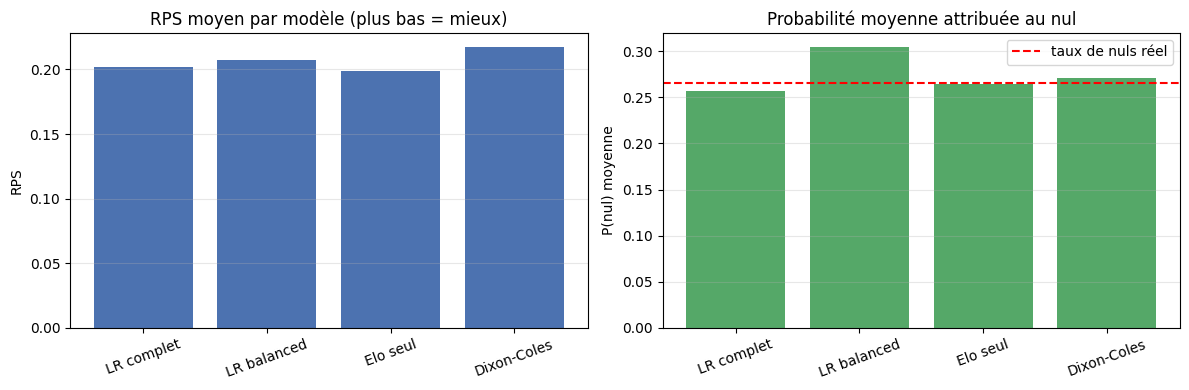

In [16]:
# ----------------------------------------------------------
# Visualisation : RPS (qualité globale) et masse de proba sur le nul
# ----------------------------------------------------------
models = list(summary.index)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models, summary["RPS"], color="#4C72B0")
axes[0].set_title("RPS moyen par modèle (plus bas = mieux)")
axes[0].set_ylabel("RPS")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(models, summary["P(nul)_moy"], color="#55A868")
axes[1].axhline(np.concatenate(actual_draw).mean(), color="red", linestyle="--",
                label="taux de nuls réel")
axes[1].set_title("Probabilité moyenne attribuée au nul")
axes[1].set_ylabel("P(nul) moyenne")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Ce que le chantier B apprend (résultat honnête)

**Aucune des trois pistes ne bat l'Elo seul**, y compris à l'aune du RPS :

| Modèle | Accuracy | Log-loss | RPS | Rappel nul | P(nul) moy. |
|---|---:|---:|---:|---:|---:|
| LR complet | 0.526 | 1.012 | 0.202 | 0.02 | 0.257 |
| LR balanced | 0.513 | 1.036 | 0.207 | **0.24** | 0.305 |
| Elo seul | 0.528 | **0.994** | **0.199** | 0.00 | 0.265 |
| Dixon-Coles | 0.480 | 1.050 | 0.218 | 0.02 | 0.271 |

Le mécanisme profond, et c'est le vrai enseignement :

- **Le « problème des nuls » n'est PAS un problème de calibration.** Tous les modèles attribuent en moyenne ≈ 0.26 de probabilité au nul, soit exactement le taux réel de nuls (0.266). Ils ne sous-estiment donc pas les nuls *en masse*. Le nul n'est simplement **presque jamais l'issue la plus probable** d'un match donné : voilà pourquoi le rappel est ≈ 0. C'est une propriété intrinsèque du football, pas un défaut du modèle.
- **`class_weight="balanced"` traite le symptôme, pas la cause.** Il fait bien monter le rappel des nuls (0.02 → 0.24), mais en sur-prédisant les nuls (P(nul) passe à 0.305 > 0.266) : la calibration se dégrade et log-loss comme RPS empirent. Forcer des prédictions de nul, c'est parier contre l'issue la plus probable.
- **Dixon-Coles, la réponse « manuel », sous-performe ici.** Le modèle est correct (MLE convergent, ρ ≈ −0.08 qui rehausse bien les nuls, avantage domicile ≈ 0.23), mais il **jette le signal Elo** — le plus prédictif sur ces données — pour ne s'appuyer que sur des forces de buts estimées sur peu de saisons. Sa correction bas-scores ajoute un peu de masse aux nuls (0.271), mais c'était déjà à peu près calibré sans elle.

**Conclusion.** Le RPS confirme le classement de la log-loss (Elo devant), et le nul résiste à toutes les approches directes. La piste réellement prometteuse n'est pas « un meilleur modèle de nul » isolé, mais un **hybride** : injecter les espérances de buts (λ, μ) ou le P(nul) de Dixon-Coles comme features supplémentaires à côté d'`elo_diff`, pour combiner le pouvoir discriminant de l'Elo et la structure de buts de Dixon-Coles. À réserver pour une itération ultérieure.